In [17]:
from pathlib import Path
import os
import pydicom
import pandas as pd

In [18]:
# Veri kök klasörü
DATA_ROOT = Path(r"D:\TCIA\nsclc_raw\nsclc_radiomics")

# Örnek hasta
patient_id = "LUNG1-001"
patient_path = DATA_ROOT / patient_id

print("Patient path:", patient_path)
print("Exists:", patient_path.exists())

Patient path: D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001
Exists: True


In [19]:
# Hasta klasörü altındaki tüm .dcm dosyalarını bul
dcm_files = list(patient_path.rglob("*.dcm"))
print("Toplam .dcm dosyası:", len(dcm_files))

# İlk 5 dosyayı göster
for f in dcm_files[:5]:
    print(f)

Toplam .dcm dosyası: 136
D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1.3.6.1.4.1.32722.99.99.239341353911714368772597187099978969331\1.2.276.0.7230010.3.1.3.2323910823.20524.1597260509.554\553521b9-f9e8-4103-b04d-5f032b974b68.dcm
D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1.3.6.1.4.1.32722.99.99.239341353911714368772597187099978969331\1.3.6.1.4.1.32722.99.99.227938121586608072508444156170535578236\5bcda93e-ef26-4a58-a7b4-47832c15a000.dcm
D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1.3.6.1.4.1.32722.99.99.239341353911714368772597187099978969331\1.3.6.1.4.1.32722.99.99.298991776521342375010861296712563382046\0269d511-9a8e-4e5f-8d77-f4eae680ee2d.dcm
D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1.3.6.1.4.1.32722.99.99.239341353911714368772597187099978969331\1.3.6.1.4.1.32722.99.99.298991776521342375010861296712563382046\06737c22-c035-4058-a9db-7eaff20fb079.dcm
D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1.3.6.1.4.1.32722.99.99.239341353911714368772597187099978969331\1.3.6.1.4.1.32722.99.99

In [20]:
# İlk birkaç DICOM dosyasının modality bilgisine bakalım
rows = []

for f in dcm_files[:20]:
    try:
        ds = pydicom.dcmread(str(f), stop_before_pixels=True)
        rows.append({
            "file": str(f),
            "Modality": getattr(ds, "Modality", None),
            "SeriesDescription": getattr(ds, "SeriesDescription", None),
            "SeriesInstanceUID": getattr(ds, "SeriesInstanceUID", None),
            "StudyInstanceUID": getattr(ds, "StudyInstanceUID", None),
        })
    except Exception as e:
        rows.append({
            "file": str(f),
            "Modality": f"ERROR: {e}",
            "SeriesDescription": None,
            "SeriesInstanceUID": None,
            "StudyInstanceUID": None,
        })

pd.DataFrame(rows)

,file,Modality,SeriesDescription,SeriesInstanceUID,StudyInstanceUID
0,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,SEG,Segmentation,1.2.276.0.7230010.3.1.3.2323910823.20524.15972...,1.3.6.1.4.1.32722.99.99.2393413539117143687725...
1,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,RTSTRUCT,None,1.3.6.1.4.1.32722.99.99.2279381215866080725084...,1.3.6.1.4.1.32722.99.99.2393413539117143687725...
2,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,CT,None,1.3.6.1.4.1.32722.99.99.2989917765213423750108...,1.3.6.1.4.1.32722.99.99.2393413539117143687725...
3,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,CT,None,1.3.6.1.4.1.32722.99.99.2989917765213423750108...,1.3.6.1.4.1.32722.99.99.2393413539117143687725...
4,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,CT,None,1.3.6.1.4.1.32722.99.99.2989917765213423750108...,1.3.6.1.4.1.32722.99.99.2393413539117143687725...
5,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,CT,None,1.3.6.1.4.1.32722.99.99.2989917765213423750108...,1.3.6.1.4.1.32722.99.99.2393413539117143687725...
6,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,CT,None,1.3.6.1.4.1.32722.99.99.2989917765213423750108...,1.3.6.1.4.1.32722.99.99.2393413539117143687725...
7,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,CT,None,1.3.6.1.4.1.32722.99.99.2989917765213423750108...,1.3.6.1.4.1.32722.99.99.2393413539117143687725...
8,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,CT,None,1.3.6.1.4.1.32722.99.99.2989917765213423750108...,1.3.6.1.4.1.32722.99.99.2393413539117143687725...
9,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,CT,None,1.3.6.1.4.1.32722.99.99.2989917765213423750108...,1.3.6.1.4.1.32722.99.99.2393413539117143687725...


In [21]:
# Tüm dosyaları series bazında özetle
series_rows = []

for f in dcm_files:
    try:
        ds = pydicom.dcmread(str(f), stop_before_pixels=True)
        series_rows.append({
            "path": str(f),
            "Modality": getattr(ds, "Modality", None),
            "SeriesInstanceUID": getattr(ds, "SeriesInstanceUID", None),
            "SeriesDescription": getattr(ds, "SeriesDescription", None),
        })
    except:
        pass

df_series = pd.DataFrame(series_rows)
summary = (
    df_series.groupby(["SeriesInstanceUID", "Modality", "SeriesDescription"])
    .size()
    .reset_index(name="file_count")
    .sort_values("file_count", ascending=False)
)

summary

,SeriesInstanceUID,Modality,SeriesDescription,file_count
0,1.2.276.0.7230010.3.1.3.2323910823.20524.15972...,SEG,Segmentation,1


In [26]:
# None olan SeriesDescription alanlarını doldur
df_series_fixed = df_series.copy()
df_series_fixed["SeriesDescription"] = df_series_fixed["SeriesDescription"].fillna("UNKNOWN")

summary_fixed = (
    df_series_fixed.groupby(["SeriesInstanceUID", "Modality", "SeriesDescription"], dropna=False)
    .size()
    .reset_index(name="file_count")
    .sort_values("file_count", ascending=False)
)

summary_fixed

,SeriesInstanceUID,Modality,SeriesDescription,file_count
2,1.3.6.1.4.1.32722.99.99.2989917765213423750108...,CT,UNKNOWN,134
0,1.2.276.0.7230010.3.1.3.2323910823.20524.15972...,SEG,Segmentation,1
1,1.3.6.1.4.1.32722.99.99.2279381215866080725084...,RTSTRUCT,UNKNOWN,1


In [27]:
ct_rows = []

for f in ct_files:
    ds = pydicom.dcmread(str(f), stop_before_pixels=True)
    ct_rows.append({
        "file": str(f),
        "InstanceNumber": getattr(ds, "InstanceNumber", None),
        "ImagePositionPatient": getattr(ds, "ImagePositionPatient", None),
        "SliceLocation": getattr(ds, "SliceLocation", None),
    })

ct_df = pd.DataFrame(ct_rows)
ct_df.head()

,file,InstanceNumber,ImagePositionPatient,SliceLocation
0,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,85,"[-249.51171875, -460.51171875, -534.5]",-534.5
1,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,124,"[-249.51171875, -460.51171875, -651.5]",-651.5
2,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,36,"[-249.51171875, -460.51171875, -387.5]",-387.5
3,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,123,"[-249.51171875, -460.51171875, -648.5]",-648.5
4,D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1....,15,"[-249.51171875, -460.51171875, -324.5]",-324.5


In [28]:
ct_df[["InstanceNumber", "ImagePositionPatient", "SliceLocation"]].head(10)

,InstanceNumber,ImagePositionPatient,SliceLocation
0,85,"[-249.51171875, -460.51171875, -534.5]",-534.5
1,124,"[-249.51171875, -460.51171875, -651.5]",-651.5
2,36,"[-249.51171875, -460.51171875, -387.5]",-387.5
3,123,"[-249.51171875, -460.51171875, -648.5]",-648.5
4,15,"[-249.51171875, -460.51171875, -324.5]",-324.5
5,16,"[-249.51171875, -460.51171875, -327.5]",-327.5
6,69,"[-249.51171875, -460.51171875, -486.5]",-486.5
7,129,"[-249.51171875, -460.51171875, -666.5]",-666.5
8,65,"[-249.51171875, -460.51171875, -474.5]",-474.5
9,29,"[-249.51171875, -460.51171875, -366.5]",-366.5


In [29]:
def get_z_position(dcm_path):
    ds = pydicom.dcmread(str(dcm_path), stop_before_pixels=True)
    ipp = getattr(ds, "ImagePositionPatient", None)
    if ipp is not None and len(ipp) == 3:
        return float(ipp[2])
    return float("inf")

ct_files_sorted = sorted(ct_files, key=get_z_position)

print("İlk 3 slice:")
for f in ct_files_sorted[:3]:
    ds = pydicom.dcmread(str(f), stop_before_pixels=True)
    print(f.name, ds.ImagePositionPatient)

print("\nSon 3 slice:")
for f in ct_files_sorted[-3:]:
    ds = pydicom.dcmread(str(f), stop_before_pixels=True)
    print(f.name, ds.ImagePositionPatient)

İlk 3 slice:
a249ac9b-c72c-4fdb-951b-173f9f066c55.dcm [-249.51171875, -460.51171875, -681.5]
9306497b-602c-4a0c-ad12-5a4e290dd60c.dcm [-249.51171875, -460.51171875, -678.5]
36eea5f6-d95c-4db5-9087-ffef997abc37.dcm [-249.51171875, -460.51171875, -675.5]

Son 3 slice:
fdbe15bb-a030-4a8d-b041-b4a734125dc8.dcm [-249.51171875, -460.51171875, -288.5]
2dfd9568-6128-4d03-8f81-f0470a85d1d7.dcm [-249.51171875, -460.51171875, -285.5]
ed62c42c-c261-44c4-a4a5-0bc77fa2dac9.dcm [-249.51171875, -460.51171875, -282.5]


In [30]:
import numpy as np

ct_slices = [pydicom.dcmread(str(f)) for f in ct_files_sorted]
volume = np.stack([ds.pixel_array for ds in ct_slices], axis=0)

print("Volume shape:", volume.shape)
print("dtype:", volume.dtype)
print("min/max:", volume.min(), volume.max())

Volume shape: (134, 512, 512)
dtype: uint16
min/max: 0 4058


In [31]:
slope = float(getattr(ct_slices[0], "RescaleSlope", 1.0))
intercept = float(getattr(ct_slices[0], "RescaleIntercept", 0.0))

volume_hu = volume.astype(np.float32) * slope + intercept

print("HU volume shape:", volume_hu.shape)
print("HU min/max:", volume_hu.min(), volume_hu.max())
print("Slope:", slope)
print("Intercept:", intercept)

HU volume shape: (134, 512, 512)
HU min/max: -1024.0 3034.0
Slope: 1.0
Intercept: -1024.0


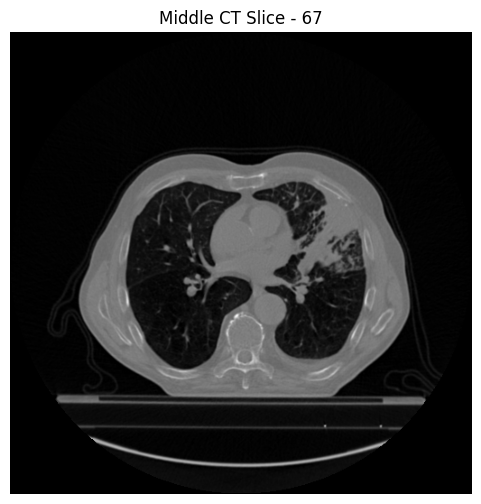

In [34]:
import matplotlib.pyplot as plt

mid_idx = volume_hu.shape[0] // 2

plt.figure(figsize=(6, 6))
plt.imshow(volume_hu[mid_idx], cmap="gray")
plt.title(f"Middle CT Slice - {mid_idx}")
plt.axis("off")
plt.show()

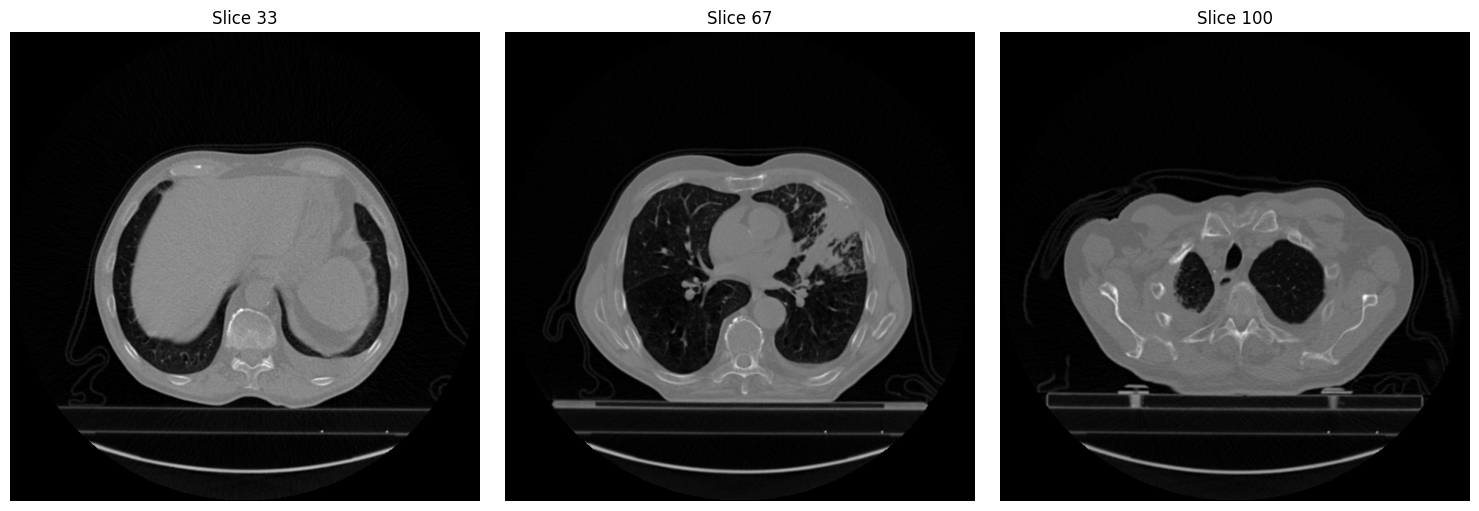

In [35]:
slice_indices = [volume_hu.shape[0]//4, volume_hu.shape[0]//2, 3*volume_hu.shape[0]//4]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, idx in zip(axes, slice_indices):
    ax.imshow(volume_hu[idx], cmap="gray")
    ax.set_title(f"Slice {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [36]:
seg_files = []

for f in dcm_files:
    try:
        ds = pydicom.dcmread(str(f), stop_before_pixels=True)
        if getattr(ds, "Modality", None) == "SEG":
            seg_files.append(f)
    except:
        pass

print("SEG dosya sayısı:", len(seg_files))
for f in seg_files:
    print(f)

SEG dosya sayısı: 1
D:\TCIA\nsclc_raw\nsclc_radiomics\LUNG1-001\1.3.6.1.4.1.32722.99.99.239341353911714368772597187099978969331\1.2.276.0.7230010.3.1.3.2323910823.20524.1597260509.554\553521b9-f9e8-4103-b04d-5f032b974b68.dcm


In [37]:
seg_ds = pydicom.dcmread(str(seg_files[0]))

print("Modality:", getattr(seg_ds, "Modality", None))
print("Rows:", getattr(seg_ds, "Rows", None))
print("Columns:", getattr(seg_ds, "Columns", None))
print("NumberOfFrames:", getattr(seg_ds, "NumberOfFrames", None))
print("SeriesDescription:", getattr(seg_ds, "SeriesDescription", None))

Modality: SEG
Rows: 512
Columns: 512
NumberOfFrames: 536
SeriesDescription: Segmentation


In [38]:
seg_array = seg_ds.pixel_array

print("SEG shape:", seg_array.shape)
print("SEG dtype:", seg_array.dtype)
print("SEG unique values:", np.unique(seg_array))

SEG shape: (536, 512, 512)
SEG dtype: uint8
SEG unique values: [0 1]


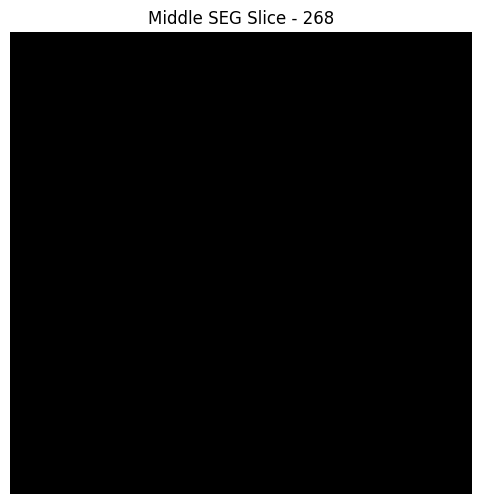

In [40]:
mid_seg_idx = seg_array.shape[0] // 2

plt.figure(figsize=(6, 6))
plt.imshow(seg_array[mid_seg_idx], cmap="gray")
plt.title(f"Middle SEG Slice - {mid_seg_idx}")
plt.axis("off")
plt.show()

In [41]:
print("CT shape :", volume_hu.shape)
print("SEG shape:", seg_array.shape)

CT shape : (134, 512, 512)
SEG shape: (536, 512, 512)


In [47]:
print("Toplam mask voxel sayısı:", int(seg_array.sum()))

Toplam mask voxel sayısı: 1903588


In [48]:
mask_per_slice = seg_array.reshape(seg_array.shape[0], -1).sum(axis=1)
nonzero_slices = np.where(mask_per_slice > 0)[0]

print("Mask olan slice sayısı:", len(nonzero_slices))
print("İlk 20 nonzero slice:", nonzero_slices[:20])

Mask olan slice sayısı: 279
İlk 20 nonzero slice: [65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84]


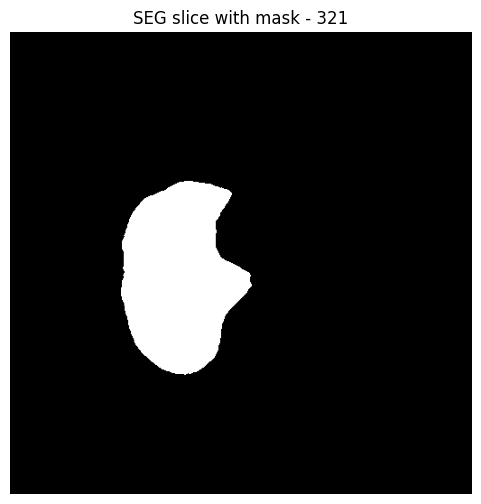

In [49]:
if len(nonzero_slices) > 0:
    idx = nonzero_slices[len(nonzero_slices) // 2]
    plt.figure(figsize=(6, 6))
    plt.imshow(seg_array[idx], cmap="gray")
    plt.title(f"SEG slice with mask - {idx}")
    plt.axis("off")
    plt.show()
else:
    print("Mask içeren slice bulunamadı.")

In [50]:
if volume_hu.shape == seg_array.shape and len(nonzero_slices) > 0:
    idx = nonzero_slices[len(nonzero_slices) // 2]

    plt.figure(figsize=(6, 6))
    plt.imshow(volume_hu[idx], cmap="gray")
    plt.imshow(seg_array[idx], cmap="Reds", alpha=0.35)
    plt.title(f"CT + SEG Overlay - slice {idx}")
    plt.axis("off")
    plt.show()
else:
    print("Shape'ler birebir aynı değil, önce hizalama yapmamız gerek.")

Shape'ler birebir aynı değil, önce hizalama yapmamız gerek.


In [56]:
pffgs = seg_ds.PerFrameFunctionalGroupsSequence

print("Toplam frame:", len(pffgs))

Toplam frame: 536


In [57]:
frame0 = pffgs[0]

print(frame0)

(0008,9124)  Derivation Image Sequence  1 item(s) ---- 
   (0008,2112)  Source Image Sequence  1 item(s) ---- 
      (0008,1150) Referenced SOP Class UID            UI: CT Image Storage
      (0008,1155) Referenced SOP Instance UID         UI: 1.3.6.1.4.1.32722.99.99.41277525157876544037153507755141737313
      (0040,A170)  Purpose of Reference Code Sequence  1 item(s) ---- 
         (0008,0100) Code Value                          SH: '121322'
         (0008,0102) Coding Scheme Designator            SH: 'DCM'
         (0008,0104) Code Meaning                        LO: 'Source image for image processing operation'
         ---------
      ---------
   (0008,9215)  Derivation Code Sequence  1 item(s) ---- 
      (0008,0100) Code Value                          SH: '113076'
      (0008,0102) Coding Scheme Designator            SH: 'DCM'
      (0008,0104) Code Meaning                        LO: 'Segmentation'
      ---------
   ---------
(0020,9111)  Frame Content Sequence  1 item(s) ---- 

In [58]:
seg_z_positions = []

for frame in pffgs:
    ipp = frame.PlanePositionSequence[0].ImagePositionPatient
    seg_z_positions.append(float(ipp[2]))

seg_z_positions[:10]

[-681.5,
 -678.5,
 -675.5,
 -672.5,
 -669.5,
 -666.5,
 -663.5,
 -660.5,
 -657.5,
 -654.5]

In [59]:
ct_z_positions = []

for f in ct_files_sorted:
    ds = pydicom.dcmread(str(f), stop_before_pixels=True)
    ipp = ds.ImagePositionPatient
    ct_z_positions.append(float(ipp[2]))

ct_z_positions[:10]

[-681.5,
 -678.5,
 -675.5,
 -672.5,
 -669.5,
 -666.5,
 -663.5,
 -660.5,
 -657.5,
 -654.5]

In [60]:
print("CT slices:", len(ct_z_positions))
print("SEG frames:", len(seg_z_positions))

CT slices: 134
SEG frames: 536


In [61]:
segment_numbers = []

for frame in pffgs:
    seg_num = frame.SegmentIdentificationSequence[0].ReferencedSegmentNumber
    segment_numbers.append(int(seg_num))

print("Unique segment numbers:", sorted(set(segment_numbers)))
print("Toplam unique segment sayısı:", len(set(segment_numbers)))

Unique segment numbers: [1, 2, 3, 4]
Toplam unique segment sayısı: 4


In [62]:
from collections import Counter

segment_counts = Counter(segment_numbers)
print(segment_counts)

Counter({1: 134, 2: 134, 3: 134, 4: 134})


In [63]:
for seg_item in seg_ds.SegmentSequence:
    print("SegmentNumber:", seg_item.SegmentNumber)
    print("SegmentLabel:", getattr(seg_item, "SegmentLabel", None))
    print("SegmentDescription:", getattr(seg_item, "SegmentDescription", None))
    print("-" * 40)

SegmentNumber: 1
SegmentLabel: Neoplasm, Primary
SegmentDescription: GTV-1
----------------------------------------
SegmentNumber: 2
SegmentLabel: Lung
SegmentDescription: Lung-Left
----------------------------------------
SegmentNumber: 3
SegmentLabel: Lung
SegmentDescription: Lung-Right
----------------------------------------
SegmentNumber: 4
SegmentLabel: Spinal cord
SegmentDescription: Spinal-Cord
----------------------------------------


In [64]:
tumor_segment_number = 1

tumor_frame_indices = [
    i for i, seg_num in enumerate(segment_numbers)
    if seg_num == tumor_segment_number
]

print("Tumor frame sayısı:", len(tumor_frame_indices))
print("İlk 10 tumor frame index:", tumor_frame_indices[:10])

Tumor frame sayısı: 134
İlk 10 tumor frame index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [65]:
tumor_seg_array = seg_array[tumor_frame_indices]

print("Tumor SEG shape:", tumor_seg_array.shape)
print("Tumor unique values:", np.unique(tumor_seg_array))
print("Toplam tumor voxel:", int(tumor_seg_array.sum()))

Tumor SEG shape: (134, 512, 512)
Tumor unique values: [0 1]
Toplam tumor voxel: 54639


In [66]:
print("CT shape       :", volume_hu.shape)
print("Tumor SEG shape:", tumor_seg_array.shape)

CT shape       : (134, 512, 512)
Tumor SEG shape: (134, 512, 512)


In [67]:
tumor_mask_per_slice = tumor_seg_array.reshape(tumor_seg_array.shape[0], -1).sum(axis=1)
tumor_nonzero_slices = np.where(tumor_mask_per_slice > 0)[0]

print("Mask olan slice sayısı:", len(tumor_nonzero_slices))
print("İlk 20 mask slice:", tumor_nonzero_slices[:20])

Mask olan slice sayısı: 21
İlk 20 mask slice: [65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84]


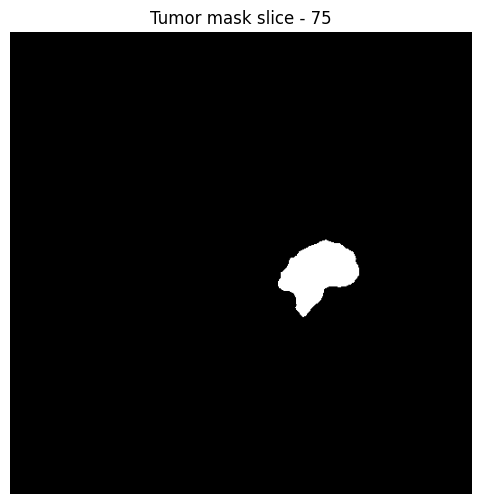

In [68]:
if len(tumor_nonzero_slices) > 0:
    idx = tumor_nonzero_slices[len(tumor_nonzero_slices) // 2]

    plt.figure(figsize=(6, 6))
    plt.imshow(tumor_seg_array[idx], cmap="gray")
    plt.title(f"Tumor mask slice - {idx}")
    plt.axis("off")
    plt.show()
else:
    print("Tümör maskesi içeren slice bulunamadı.")

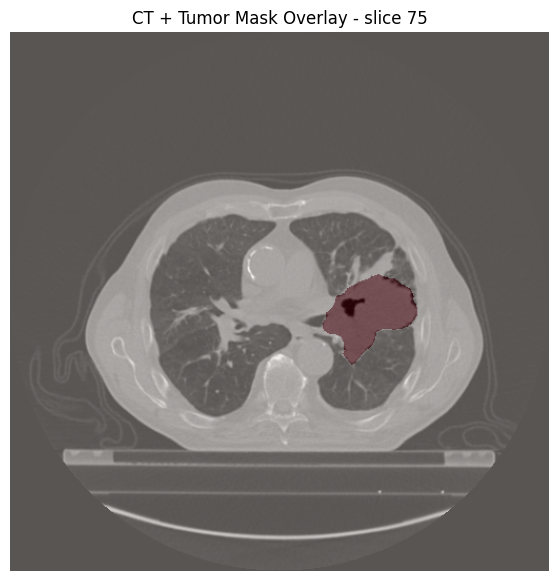

In [69]:
if volume_hu.shape == tumor_seg_array.shape and len(tumor_nonzero_slices) > 0:
    idx = tumor_nonzero_slices[len(tumor_nonzero_slices) // 2]

    plt.figure(figsize=(7, 7))
    plt.imshow(volume_hu[idx], cmap="gray")
    plt.imshow(tumor_seg_array[idx], cmap="Reds", alpha=0.35)
    plt.title(f"CT + Tumor Mask Overlay - slice {idx}")
    plt.axis("off")
    plt.show()
else:
    print("Shape'ler hala eşleşmiyor.")

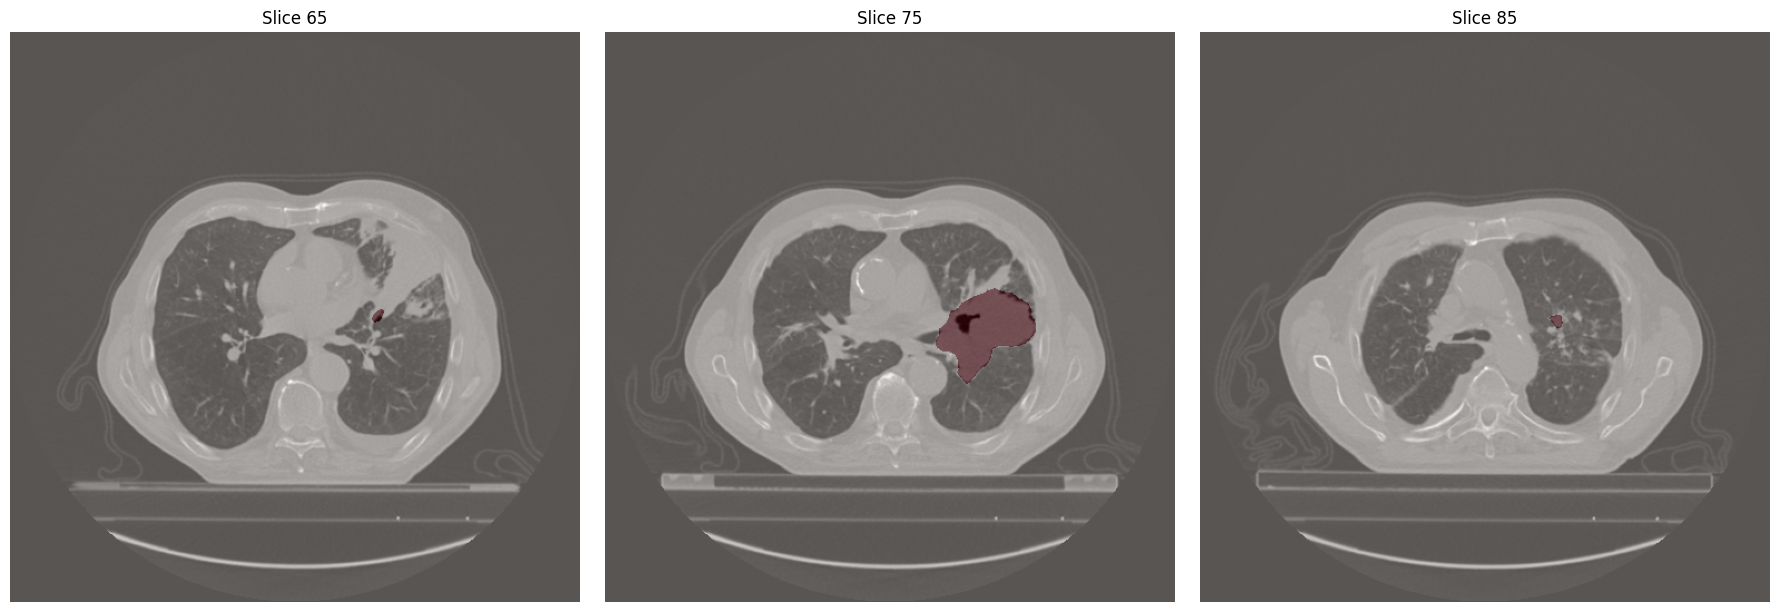

In [70]:
if len(tumor_nonzero_slices) > 0:
    selected = [
        tumor_nonzero_slices[0],
        tumor_nonzero_slices[len(tumor_nonzero_slices)//2],
        tumor_nonzero_slices[-1]
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, idx in zip(axes, selected):
        ax.imshow(volume_hu[idx], cmap="gray")
        ax.imshow(tumor_seg_array[idx], cmap="Reds", alpha=0.35)
        ax.set_title(f"Slice {idx}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()